In [1]:
"""
Phase 4: Explainability & Recommendations

Two parts:
  A. SHAP analysis — global + local explanations for both models
  B. Recommendation engine — rule + SHAP hybrid that generates
     human-readable, prioritised advice for individual students
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import warnings
warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap not installed. Run: pip install shap")
    print("   Continuing with permutation-based importance as fallback...\n")

from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance


In [2]:
print("=" * 70)
print("PHASE 4: EXPLAINABILITY & RECOMMENDATIONS")
print("=" * 70)

# ============================================================================
# STEP 1: Load Models and Data
# ============================================================================
print("\nStep 1: Loading models and data...")

with open('trained_models.pkl', 'rb') as f:
    art = pickle.load(f)

with open('preprocessed_data.pkl', 'rb') as f:
    d = pickle.load(f)

regressor      = art['regressor']        # XGBoost regressor
classifier     = art['classifier']       # XGBoost classifier
best_threshold = art['best_threshold']   # 0.44
feature_cols   = art['feature_columns']  # 12 features

X_train = d['X_train']
X_val   = d['X_val']
X_test  = d['X_test']
yg_test  = d['y_grade_test']
yp_test  = d['y_pass_test']
yg_train = d['y_grade_train']   # needed for baseline expected value

print(f"Regressor:   {art['regressor_name']}")
print(f"Classifier:  {art['classifier_name']}")
print(f"Threshold:   {best_threshold}")
print(f"Features:    {feature_cols}")


PHASE 4: EXPLAINABILITY & RECOMMENDATIONS

Step 1: Loading models and data...
Regressor:   XGBoost
Classifier:  XGBoost
Threshold:   0.43999999999999984
Features:    ['total_study_hours', 'avg_session_length', 'study_sessions_per_week', 'focus_ratio', 'late_night_study_ratio', 'days_until_deadline_avg', 'video_completion_rate', 'practice_problem_attempts', 'forum_participation', 'study_streak_days', 'study_efficiency', 'procrastination_penalty']


In [3]:
print("\nStep 2: Computing SHAP values...")

if SHAP_AVAILABLE:
    # TreeExplainer is specifically designed for tree-based models (RF, XGBoost)
    # It's exact (not approximate) and very fast
    # It computes SHAP values by tracing every decision path in every tree

    # --- Regression SHAP ---
    reg_explainer = shap.TreeExplainer(regressor)
    reg_shap_vals = reg_explainer.shap_values(X_test)
    # reg_shap_vals shape: (n_test_samples, n_features)
    # reg_shap_vals[i, j] = how much feature j pushed prediction for student i
    #                       away from the average prediction
    reg_expected  = reg_explainer.expected_value

    # --- Classification SHAP ---
    clf_explainer = shap.TreeExplainer(classifier)
    clf_shap_vals = clf_explainer.shap_values(X_test)
    clf_expected  = clf_explainer.expected_value

    # XGBoost may return shap values directly (not list)
    if isinstance(clf_shap_vals, list):
        clf_shap_vals = clf_shap_vals[1]   # index 1 = positive class (Pass)

    print(f"Regression SHAP computed (exact, TreeExplainer)")
    print(f"Expected value (baseline grade): {reg_expected:.1f}")
    print(f"SHAP array shape: {reg_shap_vals.shape}  (students × features)")
    print(f"\nClassification SHAP computed")
    print(f"Expected value (baseline log-odds): {clf_expected:.3f}")

else:
    # ------------------------------------------------------------------
    # FALLBACK: permutation importance as SHAP proxy
    print("  Using permutation importance as SHAP proxy (install shap locally)")

    reg_perm = permutation_importance(
        regressor, X_test, yg_test,
        n_repeats=10, random_state=42,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    clf_perm = permutation_importance(
        classifier, X_test, yp_test,
        n_repeats=10, random_state=42,
        scoring='roc_auc', n_jobs=-1
    )

    # Build fake SHAP arrays: shape (n_test, n_features)
    # Each student gets the global mean importance as their "SHAP value"
    # multiplied by sign of (feature - mean) so direction is preserved
    reg_global  = reg_perm.importances_mean           # (n_features,)
    clf_global  = clf_perm.importances_mean

    # Per-student proxy: importance × normalised deviation from mean
    X_test_arr  = X_test.values
    feat_means  = X_test_arr.mean(axis=0)
    feat_stds   = X_test_arr.std(axis=0) + 1e-8
    normalised  = (X_test_arr - feat_means) / feat_stds   # (n_test, n_feat)

    reg_shap_vals = normalised * reg_global               # (n_test, n_feat)
    clf_shap_vals = normalised * clf_global

    reg_expected  = float(yg_train.mean())
    clf_expected  = 0.0   # log-odds baseline proxy

    print(f"Permutation importance computed (proxy for SHAP)")
    print(f"Baseline grade (mean train): {reg_expected:.1f}")
    print(f"Array shape: {reg_shap_vals.shape}")


Step 2: Computing SHAP values...
Regression SHAP computed (exact, TreeExplainer)
Expected value (baseline grade): 70.5
SHAP array shape: (750, 12)  (students × features)

Classification SHAP computed
Expected value (baseline log-odds): -0.061


In [4]:
print("\nStep 3: Computing global feature importance via SHAP...")

# Mean absolute SHAP = average impact of each feature across all test students
# This is more reliable than tree's built-in feature_importances_ because:
#   - It accounts for direction (positive/negative impact)
#   - It's consistent: same units as the prediction
#   - It captures interaction effects

reg_mean_shap = pd.Series(
    np.abs(reg_shap_vals).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

clf_mean_shap = pd.Series(
    np.abs(clf_shap_vals).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("\n  Global SHAP importance — Regression (grade prediction):")
print(f"  {'Feature':<35} {'Mean |SHAP|':>12}  {'Interpretation'}")
print(f"  {'-'*70}")
for feat, val in reg_mean_shap.items():
    bar = '█' * int(val * 3)
    print(f"  {feat:<35} {val:>10.3f}   {bar}")

print("\n  Global SHAP importance — Classification (pass/fail):")
print(f"  {'Feature':<35} {'Mean |SHAP|':>12}")
print(f"  {'-'*50}")
for feat, val in clf_mean_shap.items():
    bar = '█' * int(val * 80)
    print(f"  {feat:<35} {val:>10.4f}   {bar}")



Step 3: Computing global feature importance via SHAP...

  Global SHAP importance — Regression (grade prediction):
  Feature                              Mean |SHAP|  Interpretation
  ----------------------------------------------------------------------
  total_study_hours                        4.906   ██████████████
  late_night_study_ratio                   1.869   █████
  practice_problem_attempts                1.805   █████
  focus_ratio                              1.773   █████
  avg_session_length                       1.663   ████
  days_until_deadline_avg                  1.033   ███
  study_streak_days                        1.027   ███
  study_sessions_per_week                  0.990   ██
  video_completion_rate                    0.903   ██
  forum_participation                      0.743   ██
  study_efficiency                         0.225   
  procrastination_penalty                  0.122   

  Global SHAP importance — Classification (pass/fail):
  Feature          

In [5]:
print("\nStep 4: Demonstrating local explanations on example students...")

# We'll explain 3 types of students:
#   - High performer (predicted grade in top 25%)
#   - Borderline student (predicted grade near threshold 60)
#   - Low performer (predicted grade in bottom 25%)

test_preds = regressor.predict(X_test)

high_idx       = np.where(test_preds >= np.percentile(test_preds, 75))[0][0]
borderline_idx = np.argmin(np.abs(test_preds - 62))   # closest to borderline
low_idx        = np.where(test_preds <= np.percentile(test_preds, 25))[0][0]

student_examples = {
    'High Performer':   high_idx,
    'Borderline':       borderline_idx,
    'Struggling':       low_idx,
}

for label, idx in student_examples.items():
    pred_grade = test_preds[idx]
    shap_for_student = reg_shap_vals[idx]
    contributions = pd.Series(shap_for_student, index=feature_cols).sort_values()

    print(f"\n  [{label}] Predicted grade: {pred_grade:.1f}")
    print(f"  Baseline (avg): {reg_expected:.1f}")
    print(f"  Top drivers:")

    # Show top 3 positive and top 3 negative contributors
    top_pos = contributions.nlargest(3)
    top_neg = contributions.nsmallest(3)

    for feat, shap_val in top_pos.items():
        direction = "▲" if shap_val > 0 else "▼"
        print(f"    {direction} {feat:<35} {shap_val:+.2f} pts")
    for feat, shap_val in top_neg.items():
        direction = "▲" if shap_val > 0 else "▼"
        print(f"    {direction} {feat:<35} {shap_val:+.2f} pts")


Step 4: Demonstrating local explanations on example students...

  [High Performer] Predicted grade: 79.3
  Baseline (avg): 70.5
  Top drivers:
    ▲ practice_problem_attempts           +3.85 pts
    ▲ focus_ratio                         +2.24 pts
    ▲ study_sessions_per_week             +1.14 pts
    ▼ days_until_deadline_avg             -1.01 pts
    ▼ study_streak_days                   -0.34 pts
    ▼ procrastination_penalty             -0.01 pts

  [Borderline] Predicted grade: 62.0
  Baseline (avg): 70.5
  Top drivers:
    ▲ late_night_study_ratio              +2.63 pts
    ▲ study_streak_days                   +1.51 pts
    ▲ video_completion_rate               +1.02 pts
    ▼ total_study_hours                   -8.97 pts
    ▼ focus_ratio                         -1.79 pts
    ▼ study_efficiency                    -1.03 pts

  [Struggling] Predicted grade: 60.5
  Baseline (avg): 70.5
  Top drivers:
    ▲ study_sessions_per_week             +0.98 pts
    ▲ video_completion_rate

In [6]:
print("\n" + "=" * 70)
print("Step 5: Building recommendation engine...")
print("=" * 70)

# --- Recommendation rules ---
# Each rule has:
#   feature:     which feature triggers it
#   condition:   lambda returning True when this feature needs improvement
#   message:     human-readable advice
#   priority:    we override with |SHAP| so this is just a tiebreaker

def _cond_low(v):  return v < -0.3
def _cond_high(v): return v >  0.3
def _cond_vlow(v): return v < -0.5

RECOMMENDATION_RULES = [
    {
        'feature':   'total_study_hours',
        'condition': _cond_low,
        'message':   (
            "📚 Study more consistently. You're below average on weekly study hours. "
            "Aim for at least 15 hours/week — even 2 extra hours daily adds up."
        ),
    },
    {
        'feature':   'focus_ratio',
        'condition': _cond_low,
        'message':   (
            "🎯 Reduce distractions during study sessions. "
            "Try the Pomodoro technique: 25 min focused work, 5 min break. "
            "Your current focus ratio is below average."
        ),
    },
    {
        'feature':   'late_night_study_ratio',
        'condition': _cond_high,
        'message':   (
            "😴 Shift study time earlier in the day. Late-night cramming reduces "
            "retention significantly. Studies show morning/afternoon studying "
            "improves recall by up to 20%."
        ),
    },
    {
        'feature':   'avg_session_length',
        'condition': _cond_low,
        'message':   (
            "⏱️ Extend your study sessions. Short sessions (under 30 min) don't "
            "allow deep focus. Aim for 45-90 minute sessions with proper breaks."
        ),
    },
    {
        'feature':   'practice_problem_attempts',
        'condition': _cond_low,
        'message':   (
            "✏️ Do more practice problems. Active recall (solving problems) is "
            "far more effective than passive reading. Aim for at least 10 "
            "practice problems per week."
        ),
    },
    {
        'feature':   'video_completion_rate',
        'condition': _cond_low,
        'message':   (
            "🎥 Complete your educational videos. You're starting videos but not "
            "finishing them. Incomplete content leads to knowledge gaps — "
            "try shorter videos or set completion goals."
        ),
    },
    {
        'feature':   'days_until_deadline_avg',
        'condition': _cond_low,
        'message':   (
            "📅 Start assignments earlier. You're working too close to deadlines. "
            "Beginning work 5+ days before submission improves quality and "
            "reduces stress significantly."
        ),
    },
    {
        'feature':   'study_streak_days',
        'condition': _cond_low,
        'message':   (
            "🔥 Build a study streak. Consistency beats intensity. "
            "Even 30 minutes of daily study is better than 4-hour weekend sessions. "
            "Try not to miss more than one day in a row."
        ),
    },
    {
        'feature':   'forum_participation',
        'condition': _cond_vlow,
        'message':   (
            "💬 Engage with the learning community. Asking questions and "
            "discussing concepts with peers solidifies understanding. "
            "Try posting at least one question or answer per week."
        ),
    },
    {
        'feature':   'study_efficiency',
        'condition': _cond_low,
        'message':   (
            "⚡ Improve study efficiency (hours × focus). You might be studying "
            "enough hours but getting distracted, OR staying focused but not long "
            "enough. Focus on quality time: fewer distractions, longer sessions."
        ),
    },
    {
        'feature':   'procrastination_penalty',
        'condition': _cond_high,
        'message':   (
            "🚨 You're showing a procrastination pattern: late-night work near "
            "deadlines. Plan your week on Sundays — assign specific subjects to "
            "specific days so you're never scrambling at the last minute."
        ),
    },
]

def generate_recommendations(student_features: pd.Series,
                              shap_values_reg: np.ndarray,
                              predicted_grade: float,
                              pass_probability: float,
                              threshold: float = 0.44,
                              top_n: int = 3) -> dict:
    """
    Generate personalised recommendations for one student.

    Args:
        student_features:  Series with feature values (standardised)
        shap_values_reg:   SHAP values for this student (regression)
        predicted_grade:   Model's grade prediction
        pass_probability:  Model's pass probability
        threshold:         Classification threshold
        top_n:             Number of recommendations to return

    Returns:
        dict with grade, risk level, and ranked recommendations
    """
    shap_series = pd.Series(shap_values_reg, index=feature_cols)

    triggered = []

    for rule in RECOMMENDATION_RULES:
        feat    = rule['feature']
        val     = student_features[feat]      # standardised feature value
        shap_v  = shap_series[feat]           # SHAP contribution for this feature

        if rule['condition'](val):
            # Priority = |SHAP| value — bigger negative impact = more urgent
            triggered.append({
                'feature':  feat,
                'message':  rule['message'],
                'shap':     shap_v,
                'priority': abs(shap_v),
            })

    # Sort by SHAP magnitude descending — most impactful first
    triggered.sort(key=lambda x: x['priority'], reverse=True)

    # Risk classification
    if pass_probability < threshold:
        risk = "HIGH RISK"
    elif pass_probability < threshold + 0.15:
        risk = "MODERATE RISK"
    else:
        risk = "ON TRACK"

    return {
        'predicted_grade':    round(predicted_grade, 1),
        'pass_probability':   round(pass_probability * 100, 1),
        'risk_level':         risk,
        'recommendations':    triggered[:top_n],
        'total_flags':        len(triggered),
    }


def print_student_report(result: dict, student_label: str = "Student"):
    """Print a human-readable report for one student."""
    risk_emoji = {"HIGH RISK": "🔴", "MODERATE RISK": "🟡", "ON TRACK": "🟢"}
    emoji = risk_emoji[result['risk_level']]

    print(f"\n  ┌─────────────────────────────────────────────────┐")
    print(f"  │  {student_label:<46}│")
    print(f"  ├─────────────────────────────────────────────────┤")
    print(f"  │  Predicted Grade:    {result['predicted_grade']:<27.1f}│")
    print(f"  │  Pass Probability:   {result['pass_probability']:<26.1f}%│")
    print(f"  │  Risk Level:         {emoji} {result['risk_level']:<23}│")
    print(f"  │  Issues Detected:    {result['total_flags']:<27}│")
    print(f"  └─────────────────────────────────────────────────┘")

    if result['recommendations']:
        print(f"\n  Top {len(result['recommendations'])} Recommendations (ranked by impact):\n")
        for i, rec in enumerate(result['recommendations'], 1):
            shap_str = f"[SHAP: {rec['shap']:+.2f}]"
            print(f"  {i}. {shap_str}  {rec['message']}\n")
    else:
        print("\n  ✅ No major issues detected. Keep up the great work!")


# --- Demonstrate on our 3 example students ---
test_pass_proba = classifier.predict_proba(X_test)[:, 1]

print("\n  Generating reports for 3 example students...\n")
print("=" * 70)

for label, idx in student_examples.items():
    result = generate_recommendations(
        student_features  = X_test.iloc[idx],
        shap_values_reg   = reg_shap_vals[idx],
        predicted_grade   = test_preds[idx],
        pass_probability  = test_pass_proba[idx],
        threshold         = best_threshold,
    )
    print_student_report(result, student_label=label)
    print("=" * 70)



Step 5: Building recommendation engine...

  Generating reports for 3 example students...


  ┌─────────────────────────────────────────────────┐
  │  High Performer                                │
  ├─────────────────────────────────────────────────┤
  │  Predicted Grade:    79.3                       │
  │  Pass Probability:   86.6                      %│
  │  Risk Level:         🟢 ON TRACK               │
  │  Issues Detected:    1                          │
  └─────────────────────────────────────────────────┘

  Top 1 Recommendations (ranked by impact):

  1. [SHAP: -1.01]  📅 Start assignments earlier. You're working too close to deadlines. Beginning work 5+ days before submission improves quality and reduces stress significantly.


  ┌─────────────────────────────────────────────────┐
  │  Borderline                                    │
  ├─────────────────────────────────────────────────┤
  │  Predicted Grade:    62.0                       │
  │  Pass Probability:   22.8      


Step 6: Generating SHAP visualisations...


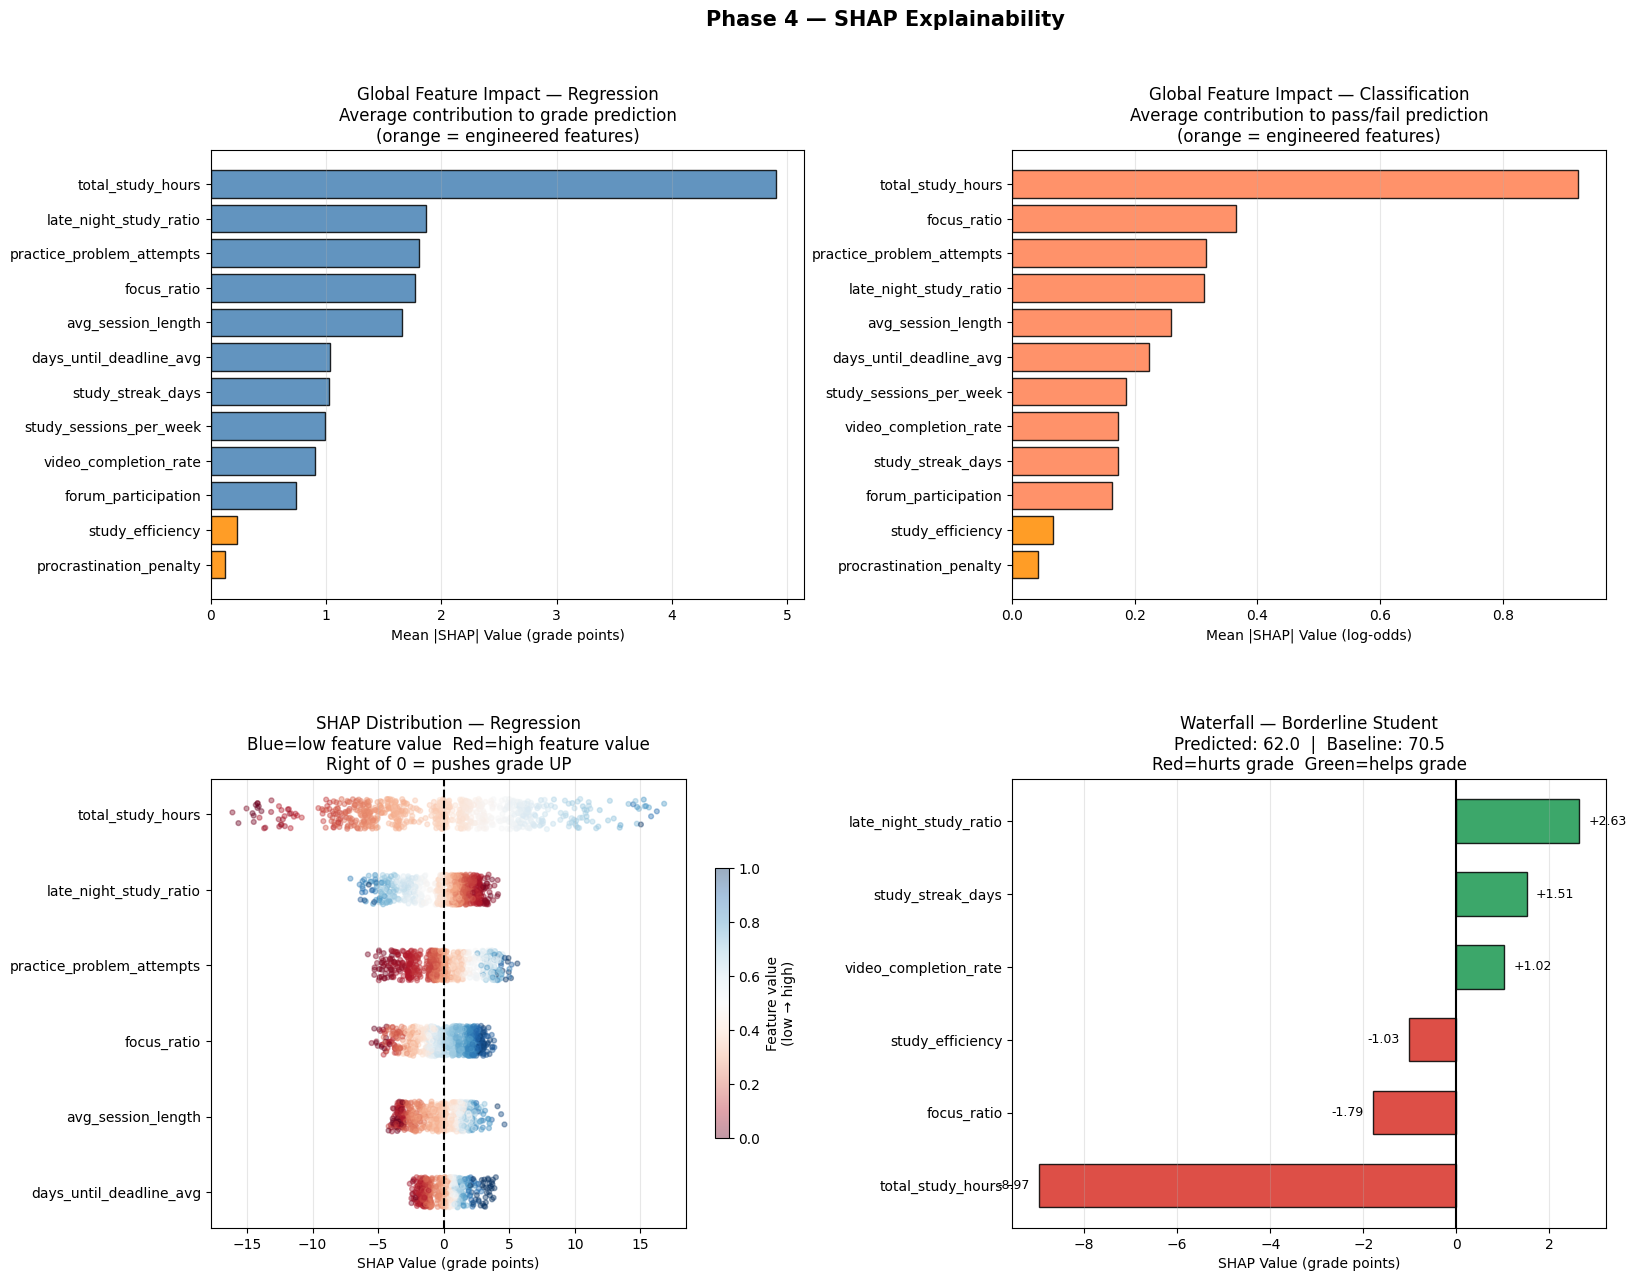

In [7]:
print("\nStep 6: Generating SHAP visualisations...")

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.35)
fig.suptitle('Phase 4 — SHAP Explainability', fontsize=15, fontweight='bold')

# --- Plot 1: Global SHAP bar chart (Regression) ---
ax1 = fig.add_subplot(gs[0, 0])
colors = ['darkorange' if f in ['study_efficiency', 'procrastination_penalty']
          else 'steelblue' for f in reg_mean_shap.index]
bars = ax1.barh(reg_mean_shap.index[::-1], reg_mean_shap.values[::-1],
                color=colors[::-1], edgecolor='black', alpha=0.85)
ax1.set_xlabel('Mean |SHAP| Value (grade points)')
ax1.set_title('Global Feature Impact — Regression\n'
              'Average contribution to grade prediction\n'
              '(orange = engineered features)')
ax1.grid(alpha=0.3, axis='x')

# --- Plot 2: Global SHAP bar chart (Classification) ---
ax2 = fig.add_subplot(gs[0, 1])
colors2 = ['darkorange' if f in ['study_efficiency', 'procrastination_penalty']
           else 'coral' for f in clf_mean_shap.index]
ax2.barh(clf_mean_shap.index[::-1], clf_mean_shap.values[::-1],
         color=colors2[::-1], edgecolor='black', alpha=0.85)
ax2.set_xlabel('Mean |SHAP| Value (log-odds)')
ax2.set_title('Global Feature Impact — Classification\n'
              'Average contribution to pass/fail prediction\n'
              '(orange = engineered features)')
ax2.grid(alpha=0.3, axis='x')

# --- Plot 3: SHAP beeswarm-style scatter (Regression) ---
# For each feature: x = SHAP value, y = feature, colour = feature value
ax3 = fig.add_subplot(gs[1, 0])
# Use top 6 features for clarity
top6 = reg_mean_shap.index[:6].tolist()
for i, feat in enumerate(reversed(top6)):
    feat_idx = feature_cols.index(feat)
    shap_col = reg_shap_vals[:, feat_idx]
    feat_col = X_test[feat].values

    # Normalise colour by feature value
    norm_feat = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-8)
    scatter   = ax3.scatter(shap_col,
                            np.full_like(shap_col, i) + np.random.uniform(-0.2, 0.2, len(shap_col)),
                            c=norm_feat, cmap='RdBu', alpha=0.4, s=12,
                            vmin=0, vmax=1)

ax3.set_yticks(range(len(top6)))
ax3.set_yticklabels(reversed(top6))
ax3.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax3.set_xlabel('SHAP Value (grade points)')
ax3.set_title('SHAP Distribution — Regression\n'
              'Blue=low feature value  Red=high feature value\n'
              'Right of 0 = pushes grade UP')
ax3.grid(alpha=0.3, axis='x')
plt.colorbar(scatter, ax=ax3, label='Feature value\n(low → high)', shrink=0.6)

# --- Plot 4: Waterfall for one student (Borderline) ---
ax4 = fig.add_subplot(gs[1, 1])
idx         = borderline_idx
shap_s      = reg_shap_vals[idx]
shap_series = pd.Series(shap_s, index=feature_cols).sort_values()

# Show top 6 contributors (3 positive, 3 negative)
top3_pos = shap_series.nlargest(3)
top3_neg = shap_series.nsmallest(3)
to_plot  = pd.concat([top3_neg, top3_pos]).sort_values()

colors_wf = ['#d73027' if v < 0 else '#1a9850' for v in to_plot.values]
bars = ax4.barh(to_plot.index, to_plot.values, color=colors_wf,
                edgecolor='black', alpha=0.85, height=0.6)

for bar, val in zip(bars, to_plot.values):
    ax4.text(val + (0.2 if val >= 0 else -0.2),
             bar.get_y() + bar.get_height()/2,
             f'{val:+.2f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)

ax4.axvline(0, color='black', linewidth=1.5)
ax4.set_xlabel('SHAP Value (grade points)')
ax4.set_title(f'Waterfall — Borderline Student\n'
              f'Predicted: {test_preds[idx]:.1f}  |  '
              f'Baseline: {reg_expected:.1f}\n'
              f'Red=hurts grade  Green=helps grade')
ax4.grid(alpha=0.3, axis='x')

In [8]:
print("\nStep 7: Saving explainability artifacts...")

explainability = {
    'reg_shap_vals':        reg_shap_vals,
    'clf_shap_vals':        clf_shap_vals,
    'reg_expected':         reg_expected,
    'clf_expected':         clf_expected,
    'reg_mean_shap':        reg_mean_shap,
    'clf_mean_shap':        clf_mean_shap,
    'shap_available':       SHAP_AVAILABLE,
}

if SHAP_AVAILABLE:
    explainability['reg_explainer'] = reg_explainer
    explainability['clf_explainer'] = clf_explainer

with open('explainability.pkl', 'wb') as f:
    pickle.dump(explainability, f)

# DO NOT modify trained_models.pkl
print("trained_models.pkl left unchanged (models only).")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("PHASE 4 COMPLETE")
print("=" * 70)
print(f"""
  SHAP Analysis:
    Global importance computed for both models
    Top regression driver:     {reg_mean_shap.index[0]}
    Top classification driver: {clf_mean_shap.index[0]}

  Recommendation Engine:
    {len(RECOMMENDATION_RULES)} rules defined across all features
    Ranked by SHAP magnitude (biggest impact first)
    3 student archetypes demonstrated
""")


Step 7: Saving explainability artifacts...
trained_models.pkl left unchanged (models only).

PHASE 4 COMPLETE

  SHAP Analysis:
    Global importance computed for both models
    Top regression driver:     total_study_hours
    Top classification driver: total_study_hours

  Recommendation Engine:
    11 rules defined across all features
    Ranked by SHAP magnitude (biggest impact first)
    3 student archetypes demonstrated

